In [2]:
from collect import *
from extract import *
from run_tests import *
from additional_suite.entropy_estimator import min_entropy_nist_90b, calculate_safe_compression_ratio

In [8]:
collect(2_100_000, "data.bin", baud_rate=3000000)

Найден порт: COM3 - Устройство с последовательным интерфейсом USB (COM3)
Сбор 2,100,000 отсчетов... (Ctrl+C для остановки)
  Прогресс: 2,101,248/2,100,000 (100%)

Собрано: 2,100,000 отсчетов
Время сбора: 5.6 сек
Скорость: 374,094 отсчетов/сек
Файл сохранён: data.bin (Размер: 4.01 МБ)


In [3]:
raw_bits = load_data_bin("data.bin")

Загружено 2100000 отсчетов из data.bin.


In [10]:
diff_array = np.diff(raw_bits)
diff_bits = (diff_array & 1).astype(np.uint8)

min_entropy = min_entropy_nist_90b(diff_bits)
safe_compression_ratio = calculate_safe_compression_ratio(min_entropy)

print(f"\nМин-энтропия: {min_entropy:.4f} бит/бит")
print(f"Рекомендуемый коэффициент сжатия: ≤ {safe_compression_ratio:.2f}")

                      MCV: 0.9655 бит/символ  (0.124 сек)
                Collision: 1.0000 бит/символ  (0.152 сек)
                   Markov: 0.8974 бит/символ  (0.427 сек)
              Compression: 1.0000 бит/символ  (0.580 сек)
                  t-Tuple: 0.8738 бит/символ  (1.531 сек)
                 MultiMCW: 0.9789 бит/символ  (0.478 сек)
                      Lag: 0.9299 бит/символ  (0.033 сек)
                 MultiMMC: 0.9093 бит/символ  (4.216 сек)

             Мин-энтропия: 0.8738 бит/бит
              Общее время: 7.540 сек

Мин-энтропия: 0.8738 бит/бит
Рекомендуемый коэффициент сжатия: ≤ 2.67


In [80]:
_BYTE_TO_BITS = np.unpackbits(np.arange(256, dtype=np.uint8).reshape(-1, 1), bitorder='big').reshape(256, 8)


def arx_extract_optimized(raw_data, target_bits, compression_ratio=2):
    """
    Оптимизированная версия ARX-экстрактора с улучшенной диффузией
    """
    raw_array = np.asarray(raw_data, dtype=np.uint16)
    
    low_bits = (raw_array & 1).astype(np.uint8)
    mid_bits = ((raw_array >> 4) & 1).astype(np.uint8)
    high_bits = ((raw_array >> 8) & 1).astype(np.uint8)
    
    combined_bits = (low_bits ^ mid_bits ^ high_bits)  
    
    diff_bits = np.diff(combined_bits)
    raw_bits = (diff_bits & 1).astype(np.uint8)
    
    input_block_bytes = 32
    output_bits = 256 // compression_ratio
    output_bytes = max(1, (output_bits + 7) // 8)
    
    n_blocks = min(
        len(raw_bits) // (input_block_bytes * 8),
        (target_bits + output_bytes * 8 - 1) // (output_bytes * 8)
    )
    
    if n_blocks == 0:
        return np.array([], dtype=np.int8)
    
    usable = raw_bits[:n_blocks * input_block_bytes * 8].reshape(n_blocks, input_block_bytes * 8)
    block_bytes = np.packbits(usable, axis=1, bitorder='big')
    
    result = bytearray(n_blocks * output_bytes)
    
    ARX_CONSTANTS = np.array([
        0x9E3779B97F4A7C15,  # φ
        0x6A09E667F3BCC908,  # √2
        0x243F6A8885A308D3,  # π
        0xB7E151628AED2A6A,  # e

        0xBB67AE8584CAA73B,  # √3
        0xB17217F7D1CF79AB,  # ln(2)
        0x33BA004F00621383,  # Apery
        0x93C467E37DB0C7A4,  # Euler-Maskeroni
        
        0xea7cb89f409ae845,  # Catalan
        0xc3a4294efece5322,  # Landau-Ramanujan
        0x280be920c700dedc,  # Feigenbaum α
        0x4ab50cbf18725d1d   # Feigenbaum δ
    ], dtype=np.uint64)
    
    MASK64 = np.uint64(0xFFFFFFFFFFFFFFFF)
    
    # === IV: первые 4 константы (совпадают с размером state) ===
    prev_state = ARX_CONSTANTS[:4].copy()
    
    for i in range(n_blocks):
        state = np.frombuffer(bytes(block_bytes[i]), dtype=np.uint64).copy()
        
        # === Chaining: связывание с предыдущим блоком ===
        state ^= prev_state
        
        for round_idx in range(60):
            state ^= ARX_CONSTANTS[round_idx % 12]
            state = ((state << np.uint64(13)) | (state >> np.uint64(51))) & MASK64
            state[0] ^= state[1]
            state[2] ^= state[3]
            state[1] ^= state[2]
            state[3] ^= state[0]
            state = ((state << np.uint64(17)) | (state >> np.uint64(47))) & MASK64
        
        # Сохраняем ПОЛНОЕ состояние для следующего блока
        prev_state = state.copy()
        
        out_bytes = state.tobytes()[:output_bytes]
        result[i * output_bytes : (i + 1) * output_bytes] = out_bytes
    
    result_array = np.frombuffer(bytes(result), dtype=np.uint8)
    all_bits = _BYTE_TO_BITS[result_array].ravel()
    
    return all_bits[:target_bits].astype(np.int8)

In [81]:
extracted_bits = arx_extract_optimized(raw_bits, 1_000_000, 2)
run_nist(extracted_bits)

Длина последовательности: 1000000 бит
Распределение: 0.5001 (1) / 0.4999 (0)
----------------------------------------------------------------------
Название теста                                | P-value    | Статус
----------------------------------------------------------------------
1. Frequency (Monobit) Test                   | 0.871306   | Пройден
2. Block Frequency Test                       | 0.496675   | Пройден
3. Runs Test                                  | 0.745958   | Пройден
4. Longest Run of Ones in a Block             | 0.229462   | Пройден
5. Binary Matrix Rank Test                    | 0.300130   | Пройден
6. Spectral (DFT) Test                        | 0.654581   | Пройден
7. Non-overlapping Template (mean P)          | 0.575980   | Пройден
8. Overlapping Template Matching (m=9)        | 0.952624   | Пройден
9. Maurer's Universal Test                    | 0.906480   | Пройден
10. Linear Complexity Test                    | 0.620407   | Пройден
11. Serial Test (m=4)  

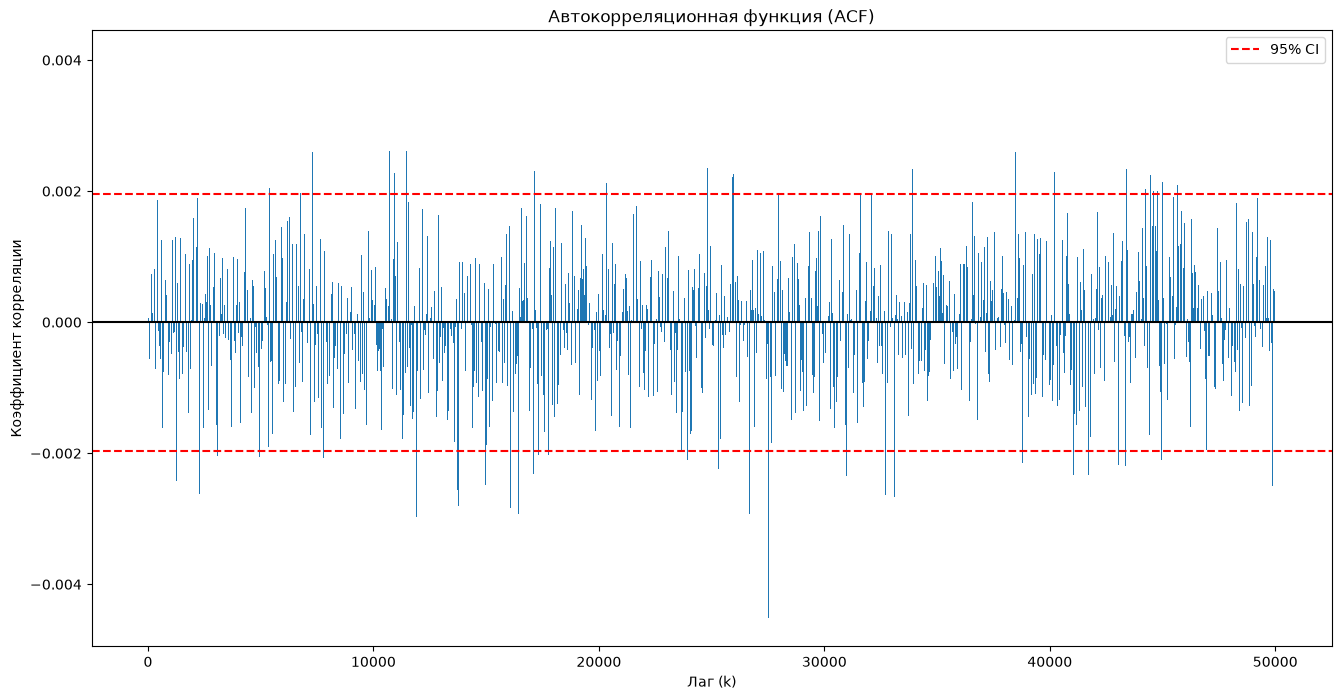

In [82]:
def plot_acf1(bits, max_lag=50):
    """Визуализация ACF"""
    bits = np.asarray(bits, dtype=int)
    X = 2 * bits - 1
    n = len(X)
    
    lags = range(1, max_lag + 1)
    acf = [np.dot(X[:n-k], X[k:]) / n for k in lags]
    
    plt.figure(figsize=(16, 8))
    plt.bar(lags, acf, width=0.8)
    plt.axhline(y=0, color='black', linestyle='-')
    plt.axhline(y=1.96 / np.sqrt(n), color='red', linestyle='--', label='95% CI')
    plt.axhline(y=-1.96 / np.sqrt(n), color='red', linestyle='--')
    plt.title('Автокорреляционная функция (ACF)')
    plt.xlabel('Лаг (k)')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

plot_acf1(extracted_bits, 50000)